# 16d — Chapter 5 Exercises: Food Security, Aggregate Risk, and Health Economics

These three exercises revisit Chapter 5's probabilistic risk-quantification
toolkit from three angles: log-normal food-security prevalence modeling
(Exercise 1), the exact Poisson-Binomial aggregate-risk distribution
(Exercise 3), and health-economics survival/life-expectancy/Value-of-
Statistical-Life calculations (Exercise 4, focused on Question 8.e --
Questions 6.a-c and 7.c are left undeveloped and disclosed as such below
rather than built out). Grouped together as the closed-form and
small-numerical-integration risk-quantification exercises, distinct from
the ODE-based biodiversity dynamics covered in `16c`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm
from scipy.integrate import quad
from scipy.special import gamma as gamma_fn

color_blue   = "#1f77b4"
color_red    = "#d62728"
color_green  = "#2ca02c"
color_violet = "#ff33ff"
color_black  = "#000000"

plt.rcParams["figure.dpi"] = 100


def lognpdf(x, mu, sigma):
    '''PDF of a log-normal distribution: log(X) ~ N(mu, sigma^2).'''
    return lognorm.pdf(x, s=sigma, scale=np.exp(mu))


## Exercise 1 — Prevalence of Undernourishment (PoU)

Dietary energy supply `X` and requirement `R` are modeled as log-normal:
`log(X)~N(μ_x,σ_x²)`, `log(R)~N(μ_r,σ_r²)`, with `μ_x=7.50`, `σ_x=0.20`,
`μ_r=7.20`, `σ_r=0.05` (medians `e^{7.5}≈1808` and `e^{7.2}≈1339`
kcal/capita/day -- supply exceeding requirement on average, as expected).


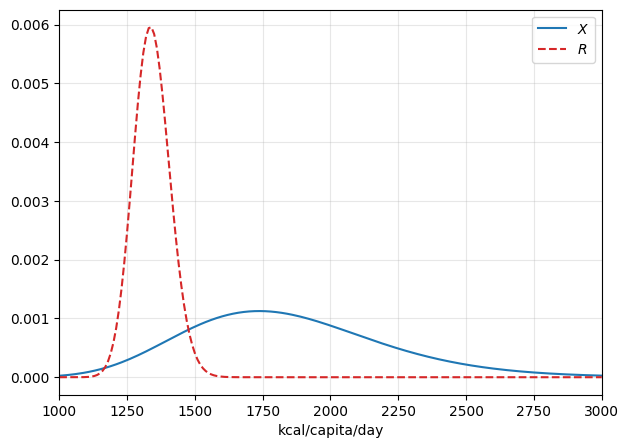

In [2]:
mu_x, sigma_x = 7.50, 0.20
mu_r, sigma_r = 7.20, 0.05

# Question 1.b -- the two log-normal densities
x_grid = np.arange(1000, 3000 + 1e-9, 10)
pdf_x = lognpdf(x_grid, mu_x, sigma_x)
pdf_r = lognpdf(x_grid, mu_r, sigma_r)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_grid, pdf_x, "-", color=color_blue, linewidth=1.5, label="$X$")
ax.plot(x_grid, pdf_r, "--", color=color_red, linewidth=1.5, label="$R$")
ax.set_xlabel("kcal/capita/day"); ax.set_xlim(1000, 3000); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

Question 1.c: treating `D=log(X)-log(R)` as approximately
`N(μ_d,σ_d²)` with `μ_d=μ_x-μ_r` and `σ_d²=σ_x²+σ_r²-2ρσ_xσ_r` for an
assumed correlation `ρ` between `log(X)` and `log(R)`, `PoU*=P(D<0)
=Φ(-μ_d/σ_d)` is the "official" FAO-style Prevalence-of-Undernourishment
formula, plotted against `ρ`.

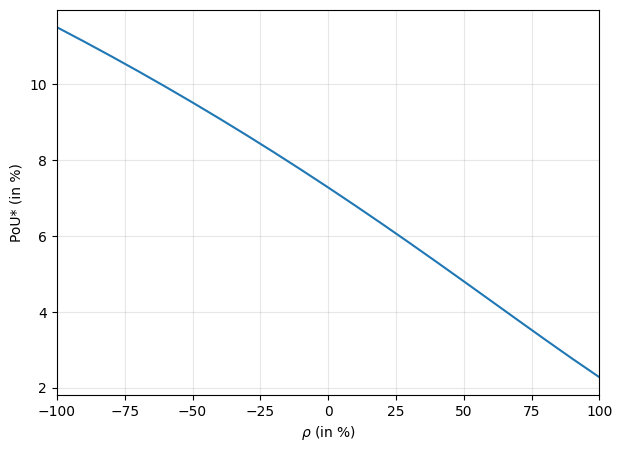

In [3]:
rho_grid = np.arange(-1.0, 1.0 + 1e-9, 0.1)
mu_d = mu_x - mu_r
sigma_d = np.sqrt(sigma_x**2 + sigma_r**2 - 2 * rho_grid * sigma_x * sigma_r)
PoU_star = norm.cdf(-mu_d / sigma_d)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(100 * rho_grid, 100 * PoU_star, "-", color=color_blue, linewidth=1.5)
ax.set_xlabel("$\\rho$ (in %)"); ax.set_ylabel("PoU* (in %)"); ax.set_xlim(-100, 100); ax.grid(True, alpha=0.3)
plt.show()

Question 1.d: holding `X`'s own distribution fixed, `PoU(r_L)
=P(X<r_L)` as a function of the minimum dietary energy requirement
threshold `r_L`.

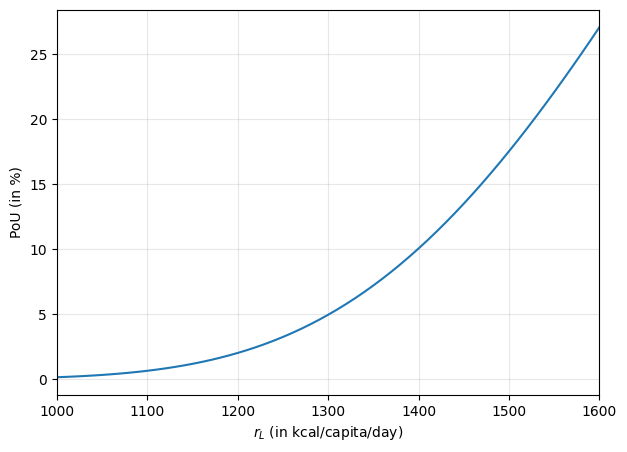

In [4]:
rL_grid = np.arange(1000, 1600 + 1e-9, 10)
PoU_d = norm.cdf(np.log(rL_grid), loc=mu_x, scale=sigma_x)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rL_grid, 100 * PoU_d, "-", color=color_blue, linewidth=1.5)
ax.set_xlabel("$r_L$ (in kcal/capita/day)"); ax.set_ylabel("PoU (in %)")
ax.set_xlim(1000, 1600); ax.grid(True, alpha=0.3)
plt.show()

Question 1.e: for each `ρ`, there is a unique threshold
`r_L*(ρ)=exp(μ_x-μ_dσ_x/σ_d)` at which the Question-1.d definition of PoU
exactly reconciles with Question 1.c's `PoU*` -- verified below as an
explicit equality check (not just a printout) by comparing `PoU*` and
`PoU(r_L*(ρ))` side by side.


 rho  PoU_star (%)  PoU(r_L*) (%)
-1.0        11.507         11.507
-0.9        11.129         11.129
-0.8        10.742         10.742
-0.7        10.345         10.345
-0.6         9.939          9.939
-0.5         9.522          9.522
-0.4         9.094          9.094
-0.3         8.656          8.656
-0.2         8.208          8.208
-0.1         7.749          7.749
-0.0         7.281          7.281
 0.1         6.802          6.802
 0.2         6.314          6.314
 0.3         5.818          5.818
 0.4         5.314          5.314
 0.5         4.805          4.805
 0.6         4.292          4.292
 0.7         3.778          3.778
 0.8         3.267          3.267
 0.9         2.764          2.764
 1.0         2.275          2.275

max|PoU_star - PoU(r_L*)| = 3.89e-16  (should be ~0: r_L* is defined precisely so these match)


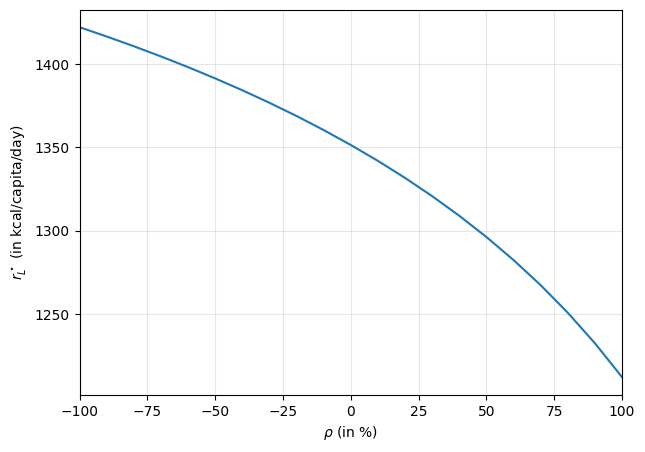

In [5]:
rL_star = np.exp(mu_x - mu_d * sigma_x / sigma_d)
PoU_at_rL_star = norm.cdf(np.log(rL_star), loc=mu_x, scale=sigma_x)

df_1e = pd.DataFrame({"rho": rho_grid, "PoU_star (%)": 100 * PoU_star, "PoU(r_L*) (%)": 100 * PoU_at_rL_star})
print(df_1e.round(3).to_string(index=False))
max_dev = np.max(np.abs(PoU_star - PoU_at_rL_star))
print(f"\nmax|PoU_star - PoU(r_L*)| = {max_dev:.2e}  (should be ~0: r_L* is defined precisely so these match)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(100 * rho_grid, rL_star, "-", color=color_blue, linewidth=1.5)
ax.set_xlabel("$\\rho$ (in %)"); ax.set_ylabel("$r_L^\\star$ (in kcal/capita/day)")
ax.set_xlim(-100, 100); ax.grid(True, alpha=0.3)
plt.show()

### Question 2 — a national food-balance-sheet worked example

Question 2.d: a standard FAO food-balance identity, available food
quantity `Q = (Production + Imports - Exports - ΔStock) - Seed - Waste`,
for 2 commodities, converted into per-capita daily kcal supply
`μ_X=(Q1·C1+Q2·C2)/(365·N)` (`C_i` = kcal/kg calorie conversion
factors, `N` = population).

In [6]:
P     = np.array([349000, 50000])
Imp   = np.array([  1025,  9010])
Exp   = np.array([ 40000,  1000])
Stock = np.array([ -1000,  6000])
Seed  = np.array([ 45000,   500])
Waste = np.array([  9000,   500])
Q = (P + Imp - Exp - Stock) - Seed - Waste
print("Q2.d  Q (available quantity, tonnes):", Q)

N = int(1e6)
Q1, C1 = Q[0] * 1000, 3500   # tonnes -> kg, kcal/kg
Q2, C2 = Q[1] * 1000, 500
mu_X = (Q1 * C1 + Q2 * C2) / (365 * N)
print(f"Q2.d  mu_X (avg. daily per-capita supply, kcal) = {mu_X:.4f}")

Q2.d  Q (available quantity, tonnes): [257025  51010]
Q2.d  mu_X (avg. daily per-capita supply, kcal) = 2534.5000


Question 2.e: the *cross-sectional* variability of individual
requirements is estimated from a 10-point age-group sample (`x_v`,
assumed equally likely), giving a coefficient of variation `CV_X_V`; a
second, exogenous coefficient of variation `CV_X_R=20%` (measurement/
year-to-year variability) is combined in quadrature to a total
`CV_X=√(CV_X_V²+CV_X_R²)`. **Note (deliberate variable reuse):** from
here on, `mu_x`/`sigma_x` are *redefined* as the log-normal parameters
implied by `(μ_X, CV_X)` -- overwriting the Question-1 values above --
and this redefined pair is what Question 4.d below actually uses.


In [7]:
x_v = np.array([1650, 1985, 2150, 2350, 2530, 2550, 2650, 2750, 3100, 3630], dtype=float)
m_v = len(x_v)
frq_age = np.ones(m_v) / m_v
mu_X_V = np.sum(frq_age * x_v)
sigma_X_V = np.sqrt(np.sum(frq_age * (x_v - mu_X_V)**2))
CV_X_V = sigma_X_V / mu_X_V
CV_X_R = 0.20
CV_X = np.sqrt(CV_X_V**2 + CV_X_R**2)
print(f"Q2.e  mu_X_V={mu_X_V:.4f}  sigma_X_V={sigma_X_V:.4f}  CV_X_V={CV_X_V:.4f}  CV_X={CV_X:.4f}")

# mu_x, sigma_x REDEFINED here (overwriting the Q1 values), for use in Question 4.d below
sigma_x = np.sqrt(np.log(1 + CV_X**2))
mu_x = np.log(mu_X) - 0.5 * sigma_x**2
rL = 1850.0
PoU_2e = norm.cdf(np.log(rL), loc=mu_x, scale=sigma_x)
NoU = N * PoU_2e
print(f"Q2.e  mu_x={mu_x:.4f}  sigma_x={sigma_x:.4f}  PoU={100*PoU_2e:.2f}%  NoU={NoU:.0f}")


Q2.e  mu_X_V=2534.5000  sigma_X_V=533.4906  CV_X_V=0.2105  CV_X=0.2904
Q2.e  mu_x=7.7973  sigma_x=0.2845  PoU=16.75%  NoU=167451


### Question 3 — a Basal Metabolic Rate / MDER worked example

Per-age-group, per-sex weight-for-height (`weight_p = BMI_p·height²`),
Basal Metabolic Rate (Schofield-equation-style `BMR=α+β·weight`), and
Minimum Dietary Energy Requirement (`MDER=1.55·BMR`, the standard
sedentary-lifestyle physical-activity-level multiplier), averaged across
sexes and then across age groups by population-share weights.

In [8]:
age            = np.array([3.0, 6.5, 14.0, 24.0, 45.0, 70.0])
BMI_p_female   = np.array([15.5, 15.5, 17.0, 17.5, 17.5, 17.5])
BMI_p_male     = np.array([15.5, 15.5, 17.0, 18.5, 18.5, 18.5])
height_female  = np.array([0.80, 1.20, 1.55, 1.60, 1.60, 1.60])
height_male    = np.array([0.88, 1.24, 1.58, 1.72, 1.72, 1.72])
BMI_p  = np.column_stack([BMI_p_female, BMI_p_male])
height = np.column_stack([height_female, height_male])
weight_p = BMI_p * height**2
print("Q3.a  weight_p (kg, female|male):\n", np.round(weight_p, 2))

alpha_female = np.array([-31.1, 485.9, 692.6, 486.6, 845.6, 658.5])
alpha_male   = np.array([-30.4, 504.3, 658.2, 692.2, 873.1, 587.7])
beta_female  = np.array([58.317, 20.315, 13.384, 14.818,  8.126,  9.082])
beta_male    = np.array([59.512, 22.706, 17.686, 15.057, 11.472, 11.711])
alpha = np.column_stack([alpha_female, alpha_male])
beta  = np.column_stack([beta_female, beta_male])
BMR = alpha + beta * weight_p
print("Q3.a  BMR (kcal/day, female|male):\n", np.round(BMR, 0))

MDER = 1.55 * BMR
print("Q3.a  MDER (kcal/day, female|male):\n", np.round(MDER, 0))

frq_age_3a = np.array([0.099, 0.150, 0.160, 0.18, 0.29, 0.121])
MDER_age = (MDER[:, 0] + MDER[:, 1]) / 2
MDER_mean = np.sum(frq_age_3a * MDER_age)
print(f"Q3.a  population-weighted mean MDER = {MDER_mean:.2f} kcal/day")

Q3.a  weight_p (kg, female|male):
 [[ 9.92 12.  ]
 [22.32 23.83]
 [40.84 42.44]
 [44.8  54.73]
 [44.8  54.73]
 [44.8  54.73]]
Q3.a  BMR (kcal/day, female|male):
 [[ 547.  684.]
 [ 939. 1045.]
 [1239. 1409.]
 [1150. 1516.]
 [1210. 1501.]
 [1065. 1229.]]
Q3.a  MDER (kcal/day, female|male):
 [[ 848. 1060.]
 [1456. 1620.]
 [1921. 2184.]
 [1783. 2350.]
 [1875. 2326.]
 [1651. 1904.]]
Q3.a  population-weighted mean MDER = 1849.90 kcal/day


### Question 4.d — numerical vs. analytical expected food deficit

`FD = E[(r̄-X)⁺·1{X<r_L}]` (expected shortfall below a reference
requirement `r̄=2500`, truncated to `X<r_L`), computed two ways: direct
numerical integration of `g(x)=(r̄-x)·f_X(x)` over `[0,r_L]`, and a
closed-form log-normal partial-moment formula. Uses the **redefined**
`mu_x`/`sigma_x`/`rL` from Question 2.e above (not the Question-1
values).


In [9]:
r_bar = 2500.0


def g_x(x):
    return (r_bar - x) * lognpdf(x, mu_x, sigma_x)


numerical_FD, _ = quad(g_x, 0, rL)
analytical_FD = (r_bar * norm.cdf((np.log(rL) - mu_x) / sigma_x)
                  - np.exp(mu_x + 0.5 * sigma_x**2) * norm.cdf((np.log(rL) - mu_x - sigma_x**2) / sigma_x))
print(f"Q4.d  numerical_FD={numerical_FD:.4f}   analytical_FD={analytical_FD:.4f}   "
      f"diff={abs(numerical_FD-analytical_FD):.2e}")

Q4.d  numerical_FD=150.2968   analytical_FD=150.2968   diff=3.69e-13


## Exercise 3 — exact Poisson-Binomial aggregate-risk PMF

The Poisson-Binomial distribution has no ready-made implementation in
the standard scientific-Python stack, so the PMF functions below are
built from first principles. It is the exact distribution of `K=Σ B_i`,
a sum of `n` **independent but not identically distributed** Bernoulli
indicators with success probabilities `p_i` (e.g. `n` insurance
policies/obligors each independently defaulting with its own
probability). Two independent algorithms are implemented for the same
exact distribution -- the same two standard textbook methods used by the
well-known `poibin` R package: method 1, a direct DP/convolution
recursion; method 2, the discrete Fourier transform of the
characteristic function. Both are exact (not approximations of each
other), so they should agree to floating-point precision -- a genuine
algorithmic cross-check, further verified below against brute-force
enumeration for these small `n≤5` cases. (One implementation bug caught
during development: the DFT-CF inversion needs `np.fft.fft(χ)/L`, not
`np.fft.ifft(χ)` -- numpy's `ifft` uses the opposite sign convention in
its exponent and silently returns the *reversed* PMF; caught immediately
by the brute-force cross-check below and fixed.)


In [10]:
def pdf_poisson_binomial_dp(p):
    '''Method 1: direct DP/convolution recursion.'''
    p = np.asarray(p, dtype=float)
    pmf = np.array([1.0])
    for pi in p:
        pmf = np.concatenate([pmf, [0.0]]) * (1 - pi) + np.concatenate([[0.0], pmf]) * pi
    k = np.arange(len(pmf))
    return k, pmf


def pdf_poisson_binomial_dft(p):
    '''Method 2: DFT of the characteristic function (Fernandez & Williams 2010 / poibin's 'DFT-CF').'''
    p = np.asarray(p, dtype=float)
    n = len(p)
    L = n + 1
    ell = np.arange(L)
    omega = 2 * np.pi * ell / L
    exp_iw = np.exp(1j * omega)
    chi = np.prod(1 - p[:, None] + p[:, None] * exp_iw[None, :], axis=0)
    # np.fft.fft(chi)/L matches the DFT-CF inversion formula's sign convention
    # (pmf[k]=(1/L)*sum_l chi(omega_l)*exp(-i*omega_l*k)); np.fft.ifft uses the opposite
    # sign and gives the *reversed* PMF instead -- verified against brute-force enumeration.
    pmf = np.real(np.fft.fft(chi)) / L
    k = np.arange(L)
    return k, pmf


def pdf_poisson_binomial_brute_force(p):
    '''Exact brute-force enumeration over all 2^n outcomes -- feasible only for small n,
    used here purely as an independent cross-check of the two methods above.'''
    from itertools import product
    p = np.asarray(p, dtype=float)
    n = len(p)
    pmf = np.zeros(n + 1)
    for outcome in product([0, 1], repeat=n):
        outcome = np.array(outcome)
        prob = np.prod(np.where(outcome == 1, p, 1 - p))
        pmf[outcome.sum()] += prob
    return np.arange(n + 1), pmf

In [11]:
def run_poisson_binomial_example(p, label):
    k1, pmf1 = pdf_poisson_binomial_dp(p)
    k2, pmf2 = pdf_poisson_binomial_dft(p)
    k3, pmf3 = pdf_poisson_binomial_brute_force(p)
    df = pd.DataFrame({"k": k1, "pmf (DP, %)": 100 * pmf1, "pmf (DFT-CF, %)": 100 * pmf2,
                        "pmf (brute force, %)": 100 * pmf3})
    print(f"--- {label} ---")
    print(df.round(2).to_string(index=False))
    Sa = p.sum()
    m1 = np.sum(k1 * pmf1)
    print(f"E[K] via sum(k*pmf) = {m1:.4f}   E[K] via sum(p_i) = {Sa:.4f}   "
          f"(should match: E[sum of independent Bernoullis] = sum of their means)")
    max_dev_dft = np.max(np.abs(pmf1 - pmf2))
    max_dev_bf = np.max(np.abs(pmf1 - pmf3))
    print(f"max|DP-DFT|={max_dev_dft:.2e}   max|DP-brute force|={max_dev_bf:.2e}")
    return k1, pmf1


# Question 1
p_q1 = np.array([0.20, 0.30, 0.10, 0.65, 0.10])
run_poisson_binomial_example(p_q1, "Question 1")

--- Question 1 ---
 k  pmf (DP, %)  pmf (DFT-CF, %)  pmf (brute force, %)
 0        15.88            15.88                 15.88
 1        43.78            43.79                 43.78
 2        30.85            30.85                 30.85
 3         8.48             8.48                  8.48
 4         0.97             0.97                  0.97
 5         0.04             0.04                  0.04
E[K] via sum(k*pmf) = 1.3500   E[K] via sum(p_i) = 1.3500   (should match: E[sum of independent Bernoullis] = sum of their means)
max|DP-DFT|=1.11e-16   max|DP-brute force|=1.39e-17


(array([0, 1, 2, 3, 4, 5]),
 array([1.5876e-01, 4.3785e-01, 3.0850e-01, 8.4800e-02, 9.7000e-03,
        3.9000e-04]))

In [12]:
# Question 2 -- claims probabilities implied by a "pick a of A" hazard model
A, a = 10, 2
n_i = np.array([10, 4, 25, 6, 8])
pi_a = a / A
p_q2 = 1 - (1 - pi_a) ** n_i
print("Q2  implied claim probabilities p_i (%):", np.round(100 * p_q2, 2))
run_poisson_binomial_example(p_q2, "Question 2")
print()

Q2  implied claim probabilities p_i (%): [89.26 59.04 99.62 73.79 83.22]
--- Question 2 ---
 k  pmf (DP, %)  pmf (DFT-CF, %)  pmf (brute force, %)
 0         0.00             0.00                  0.00
 1         0.21             0.21                  0.21
 2         3.45             3.45                  3.45
 3        19.78            19.78                 19.78
 4        44.32            44.32                 44.32
 5        32.24            32.24                 32.24
E[K] via sum(k*pmf) = 4.0493   E[K] via sum(p_i) = 4.0493   (should match: E[sum of independent Bernoullis] = sum of their means)
max|DP-DFT|=1.04e-16   max|DP-brute force|=5.55e-17



## Exercise 4 — survival analysis and Value-of-Statistical-Life

**Questions 6.a-c and 7.c are left undeveloped** (Weibull-vs-exponential
survival curve comparisons, discounted life-expectancy `LE(t;ϱ)`, and
quality-adjusted life expectancy `QALE` curves) -- disclosed here rather
than built out. Only the Weibull survival-function setup (needed
downstream) and Question 8.e are covered below.


In [13]:
m = 70.0
lam = 1.0 / m
b = 5.0
a_weib = m / gamma_fn(1 + 1 / b)
print(f"Weibull survival parameters: lambda={lam:.5f}  a={a_weib:.5f}  b={b:.5f}")


def S_exp(t):
    return np.exp(-lam * t)


def S_weibull(t):
    return np.exp(-(t / a_weib) ** b)

Weibull survival parameters: lambda=0.01429  a=76.23871  b=5.00000


### Question 8.e — Value-of-Statistical-Life (VSL) worked example

`VSL = v/ΔL` from a stated willingness-to-pay `v=1000` for a mortality-
risk reduction `ΔL=1/10,000` -- giving `VSL=$10` million, a figure in
line with real-world regulatory VSL estimates (a useful sanity check in
itself). Life Expectancy (`LE`) and Quality-Adjusted Life Expectancy
(`QALE`, using a 3-piece linear quality-of-life decay `QoL(t)`) are
computed by numerical integration of the discounted Weibull survival
function at 3 ages (`t=0,40,80`) and 2 discount rates (`ϱ=0%,3%`).
`VSLY=VSL/LE` (value per life-year) and `VQALY=VSL/QALE` (value per
quality-adjusted life-year) are derived both ways: starting from the
stated `VSL` (deriving `VSLY`,`VQALY`), and starting from an assumed
`VSLY=$150,000` (deriving `VSL`,`VQALY`).


In [14]:
v = 1000.0
Delta_L = 1 / 10000
VSL_stated = v / Delta_L
print(f"VSL (stated) = {VSL_stated:,.0f}")

t1, kappa1, t2, kappa2, t3 = 50, 0.10, 70, 0.20, 90


def QoL(t):
    t = np.atleast_1d(t).astype(float)
    val = np.where(t < t1, 1.0,
          np.where(t < t2, 1 - kappa1 * (t - t1) / (t2 - t1),
          np.where(t < t3, 1 - kappa1 - kappa2 * (t - t2) / (t3 - t2),
                    1 - kappa1 - kappa2)))
    return val


def LE_weibull_integrand(u, t, varrho):
    return np.exp(-varrho * (u - t)) * S_weibull(u) / S_weibull(t)


def QALE_weibull_integrand(u, t, varrho):
    return np.exp(-varrho * (u - t)) * S_weibull(u) / S_weibull(t) * QoL(u)[0]


t_vector = [0, 40, 80]
varrho_vector = [0.0, 0.03]

LE = np.zeros(6)
QALE = np.zeros(6)
col_labels = []
for j, varrho in enumerate(varrho_vector):
    for i, t in enumerate(t_vector):
        col = 3 * j + i
        LE[col], _ = quad(LE_weibull_integrand, t, np.inf, args=(t, varrho))
        QALE[col], _ = quad(QALE_weibull_integrand, t, np.inf, args=(t, varrho))
        col_labels.append(f"t={t}, rho={100*varrho:.0f}%")

VSLY_from_VSL = VSL_stated / LE
VQALY_from_VSL = VSL_stated / QALE

df_from_vsl = pd.DataFrame({
    "LE (years)": LE, "QALE (years)": QALE,
    "VSL ($000s)": np.round(VSL_stated / 1000, 0),
    "VSLY ($000s)": np.round(VSLY_from_VSL / 1000, 0),
    "VQALY ($000s)": np.round(VQALY_from_VSL / 1000, 0),
}, index=col_labels)
print("--- Starting from stated VSL ---")
print(df_from_vsl.round(2).to_string())

VSLY_assumed = 150_000.0
VSL_from_VSLY = VSLY_assumed * LE
VQALY_from_VSLY = VSL_from_VSLY / QALE

df_from_vsly = pd.DataFrame({
    "LE (years)": LE, "QALE (years)": QALE,
    "VSL ($000s)": np.round(VSL_from_VSLY / 1000, 0),
    "VSLY ($000s)": np.round(VSLY_assumed / 1000, 0),
    "VQALY ($000s)": np.round(VQALY_from_VSLY / 1000, 0),
}, index=col_labels)
print("\n--- Starting from assumed VSLY=$150,000 ---")
print(df_from_vsly.round(2).to_string())

R = 5 / 100000  # a mortality risk reduction, e.g. 5-in-100,000
G = VSL_from_VSLY * LE * R
print("\nG = VSL*LE*R (implied willingness-to-pay for the risk reduction, $000s):",
      np.round(G / 1000, 0))

VSL (stated) = 10,000,000


--- Starting from stated VSL ---


              LE (years)  QALE (years)  VSL ($000s)  VSLY ($000s)  VQALY ($000s)
t=0, rho=0%        70.00         68.13      10000.0         143.0          147.0
t=40, rho=0%       31.49         29.54      10000.0         318.0          339.0
t=80, rho=0%        8.74          6.50      10000.0        1144.0         1538.0
t=0, rho=3%        28.73         28.52      10000.0         348.0          351.0
t=40, rho=3%       19.11         18.39      10000.0         523.0          544.0
t=80, rho=3%        7.19          5.38      10000.0        1390.0         1858.0

--- Starting from assumed VSLY=$150,000 ---
              LE (years)  QALE (years)  VSL ($000s)  VSLY ($000s)  VQALY ($000s)
t=0, rho=0%        70.00         68.13      10500.0         150.0          154.0
t=40, rho=0%       31.49         29.54       4723.0         150.0          160.0
t=80, rho=0%        8.74          6.50       1312.0         150.0          202.0
t=0, rho=3%        28.73         28.52       4310.0         150

## Sanity checks

In [15]:
checks = []

# Q1.b: both lognormal densities integrate to (approximately) 1 on their plotted range
area_x = np.trapezoid(pdf_x, x_grid)
checks.append(("lognpdf(X) integrates to ~1 on [1000,3000]", 0.95 < area_x < 1.01, f"area={area_x:.4f}"))
area_r = np.trapezoid(pdf_r, x_grid)
checks.append(("lognpdf(R) integrates to ~1 on [1000,3000]", 0.95 < area_r < 1.01, f"area={area_r:.4f}"))

# Q1.c/1.e identity: PoU_star matches PoU(r_L*) by construction
checks.append(("Q1.c/1.e PoU* == PoU(r_L*) identity", max_dev < 1e-8, f"max_dev={max_dev:.2e}"))

# Q1.c: PoU_star should be monotonically decreasing in rho (higher correlation between
# supply and requirement shocks reduces the mismatch risk, hence undernourishment)
checks.append(("Q1.c PoU_star monotonically decreasing in rho", bool(np.all(np.diff(PoU_star) <= 1e-12)),
               f"PoU_star range=[{PoU_star.min():.4f},{PoU_star.max():.4f}]"))

# Q1.d: PoU(r_L) should be monotonically increasing in r_L (a higher threshold is easier to be under)
checks.append(("Q1.d PoU(r_L) monotonically increasing in r_L", bool(np.all(np.diff(PoU_d) >= -1e-12)), ""))

# Q4.d: numerical vs analytical expected food deficit match closely
checks.append(("Q4.d numerical_FD ~= analytical_FD", abs(numerical_FD - analytical_FD) < 1e-2,
               f"diff={abs(numerical_FD-analytical_FD):.2e}"))

# Poisson-Binomial: all 3 methods agree, for both examples
for p_vec, label in [(p_q1, "Q1"), (p_q2, "Q2")]:
    k_dp, pmf_dp = pdf_poisson_binomial_dp(p_vec)
    _, pmf_dft = pdf_poisson_binomial_dft(p_vec)
    _, pmf_bf = pdf_poisson_binomial_brute_force(p_vec)
    checks.append((f"Poisson-Binomial {label}: DP vs DFT-CF agree", np.max(np.abs(pmf_dp - pmf_dft)) < 1e-9,
                   f"max dev={np.max(np.abs(pmf_dp-pmf_dft)):.2e}"))
    checks.append((f"Poisson-Binomial {label}: DP vs brute force agree", np.max(np.abs(pmf_dp - pmf_bf)) < 1e-9,
                   f"max dev={np.max(np.abs(pmf_dp-pmf_bf)):.2e}"))
    checks.append((f"Poisson-Binomial {label}: pmf sums to 1", abs(pmf_dp.sum() - 1.0) < 1e-9,
                   f"sum={pmf_dp.sum():.10f}"))
    checks.append((f"Poisson-Binomial {label}: E[K]=sum(p_i)", abs(np.sum(k_dp * pmf_dp) - p_vec.sum()) < 1e-9,
                   f"E[K]={np.sum(k_dp*pmf_dp):.6f}  sum(p)={p_vec.sum():.6f}"))

# Poisson-Binomial reduces to plain Binomial(n,p) when all p_i are equal
p_equal = np.full(6, 0.35)
from scipy.stats import binom
k_eq, pmf_eq = pdf_poisson_binomial_dp(p_equal)
pmf_binom = binom.pmf(k_eq, 6, 0.35)
checks.append(("Poisson-Binomial reduces to Binomial(n,p) for equal p_i",
               np.max(np.abs(pmf_eq - pmf_binom)) < 1e-9, f"max dev={np.max(np.abs(pmf_eq-pmf_binom)):.2e}"))

# Q8.e: VSL = 10 million as expected from the stated inputs
checks.append(("VSL(stated) == v/Delta_L", abs(VSL_stated - 1e7) < 1e-6, f"VSL={VSL_stated:,.0f}"))

# Q8.e: LE and QALE both decrease as t increases within the same discount rate (less life left)
for j in range(2):
    le_slice = LE[3 * j:3 * j + 3]
    checks.append((f"Q8.e LE decreasing in t (rho={100*varrho_vector[j]:.0f}%)",
                   bool(np.all(np.diff(le_slice) < 0)), f"LE={np.round(le_slice,2)}"))
    qale_slice = QALE[3 * j:3 * j + 3]
    checks.append((f"Q8.e QALE decreasing in t (rho={100*varrho_vector[j]:.0f}%)",
                   bool(np.all(np.diff(qale_slice) < 0)), f"QALE={np.round(qale_slice,2)}"))

# Q8.e: QALE <= LE always (quality-of-life factor is <= 1)
checks.append(("Q8.e QALE <= LE for every (t,rho)", bool(np.all(QALE <= LE + 1e-9)),
               f"max(QALE-LE)={np.max(QALE-LE):.2e}"))

# Q8.e: higher discount rate (rho=3% vs 0%) gives lower LE/QALE (future years discounted more)
checks.append(("Q8.e LE(rho=3%) < LE(rho=0%) at every t", bool(np.all(LE[3:6] < LE[0:3])), ""))

df_checks = pd.DataFrame(checks, columns=["check", "passed", "detail"])
print(df_checks.to_string(index=False))
assert df_checks["passed"].all(), "One or more sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")

                                                  check  passed                         detail
             lognpdf(X) integrates to ~1 on [1000,3000]    True                    area=0.9928
             lognpdf(R) integrates to ~1 on [1000,3000]    True                    area=1.0000
                    Q1.c/1.e PoU* == PoU(r_L*) identity    True               max_dev=3.89e-16
          Q1.c PoU_star monotonically decreasing in rho    True PoU_star range=[0.0228,0.1151]
          Q1.d PoU(r_L) monotonically increasing in r_L    True                               
                     Q4.d numerical_FD ~= analytical_FD    True                  diff=3.69e-13
                Poisson-Binomial Q1: DP vs DFT-CF agree    True               max dev=1.11e-16
           Poisson-Binomial Q1: DP vs brute force agree    True               max dev=1.39e-17
                     Poisson-Binomial Q1: pmf sums to 1    True               sum=1.0000000000
                     Poisson-Binomial Q1: E[K]=sum